In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np


# Načtení datového souboru
df = pd.read_csv('sklik_overview_sample.csv')

# Zobrazení základních rozměrů
print(f"Počet řádků: {df.shape[0]:,}")
print(f"Počet sloupců: {df.shape[1]}")

# Zobrazení názvů sloupců a datových typů
print("\n--- Přehled sloupců a datových typů ---")
print(df.dtypes)

# Ukázka prvních 5 řádků
print("\n--- Prvních 5 řádků datasetu ---")
df.head()

Počet řádků: 9,996
Počet sloupců: 13

--- Přehled sloupců a datových typů ---
DATE                    str
WEB_NAME                str
NETWORK                 str
DEVICE_TYPE             str
OPERATING_SYSTEM        str
GENDER                  str
AGE_GROUP               str
KRAJ                    str
IMPRESSIONS           int64
CLICKS                int64
CONVERSIONS           int64
CONVERSION_VALUE    float64
MONEY               float64
dtype: object

--- Prvních 5 řádků datasetu ---


,DATE,WEB_NAME,NETWORK,DEVICE_TYPE,OPERATING_SYSTEM,GENDER,AGE_GROUP,KRAJ,IMPRESSIONS,CLICKS,CONVERSIONS,CONVERSION_VALUE,MONEY
0,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Hlavní město Praha,87,0,0,0.0,0.93
1,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Středočeský kraj,16,0,0,0.0,0.17
2,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Jihočeský kraj,57,0,0,0.0,0.61
3,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Plzeňský kraj,52,0,0,0.0,0.55
4,2026-07-26,Aktualitky.cz,context,Desktop,ChromeOS,Žena,40 - 59,Karlovarský kraj,14,0,0,0.0,0.15


In [52]:


# 1. Převod sloupce DATE na datový typ datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# 2. Kontrola duplicit
print("--- 1. Kontrola duplicit ---")
print(f"Počet duplicitních řádků: {df.duplicated().sum()}")

# 3. Kontrola chybějících hodnot (NaN)
print("\n--- 2. Kontrola chybějících hodnot ---")
print(df.isnull().sum())

# 4. Kontrola logických anomálií
print("\n--- 3. Kontrola logických anomálií ---")
print(f"Řádky kde CLICKS > IMPRESSIONS: {(df['CLICKS'] > df['IMPRESSIONS']).sum()}")
print(f"Řádky kde CONVERSIONS > CLICKS: {(df['CONVERSIONS'] > df['CLICKS']).sum()}")

numeric_cols = ['IMPRESSIONS', 'CLICKS', 'CONVERSIONS', 'CONVERSION_VALUE', 'MONEY']
print("\nPočet záporných hodnot v číselných sloupcích:")
print((df[numeric_cols] < 0).sum())

# 5. Inspekce kategoriálních sloupců pro odhalení nekonzistencí
print("\n--- 4. Přehled kategoriálních hodnot ---")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n>>> Sloupec: {col}")
    print(df[col].value_counts(dropna=False))

--- 1. Kontrola duplicit ---
Počet duplicitních řádků: 0

--- 2. Kontrola chybějících hodnot ---
DATE                   0
WEB_NAME               0
NETWORK                0
DEVICE_TYPE          476
OPERATING_SYSTEM    2968
GENDER                 0
AGE_GROUP              0
KRAJ                   0
IMPRESSIONS            0
CLICKS                 0
CONVERSIONS            0
CONVERSION_VALUE       0
MONEY                  0
dtype: int64

--- 3. Kontrola logických anomálií ---
Řádky kde CLICKS > IMPRESSIONS: 0
Řádky kde CONVERSIONS > CLICKS: 0

Počet záporných hodnot v číselných sloupcích:
IMPRESSIONS         0
CLICKS              0
CONVERSIONS         0
CONVERSION_VALUE    0
MONEY               0
dtype: int64

--- 4. Přehled kategoriálních hodnot ---

>>> Sloupec: WEB_NAME
WEB_NAME
Kliknito.cz      1344
Pozdní Zprávy    1288
Drbárna.cz       1190
Poštovna.cz      1064
Baráky.cz        1050
Aktualitky.cz    1022
Kopačka.cz       1008
Kámoši.net        840
Blogeria.cz       644
ProTety.cz     

/var/folders/nl/l490bxmx253cbr9z92x4fwhh0000gn/T/ipykernel_723/2997143331.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [53]:
# Inspekce operačních systémů podle jednotlivých typů zařízení
df.groupby(['DEVICE_TYPE', 'OPERATING_SYSTEM']).size().unstack(fill_value=0)

OPERATING_SYSTEM,Android,ChromeOS,Tizen,Ubuntu,Windows,iOS,iPadOS,macOS
DEVICE_TYPE,,,,,,,,
Console,182,0,0,0,140,0,0,0
Desktop,98,644,0,14,602,112,0,672
EReader,84,0,0,0,0,0,0,0
MediaHub,378,0,0,0,0,0,0,0
Mobile,42,0,0,0,0,28,0,0
SmallScreen,448,0,0,0,0,0,0,0
SmartPhone,658,0,0,56,28,924,0,0
SmartWatch,70,0,0,0,0,0,0,0
Tablet,560,0,0,0,28,70,560,14


In [54]:
# 1. Nahrazení chybějících hodnot
df['DEVICE_TYPE'] = df['DEVICE_TYPE'].fillna('Neznámý')
df['OPERATING_SYSTEM'] = df['OPERATING_SYSTEM'].fillna('Neznámý')

# 2. Sjednocení mobilního provozu
df['DEVICE_TYPE'] = df['DEVICE_TYPE'].replace({'SmartPhone': 'Mobile', 'SmallScreen': 'Mobile'})

# Kontrola rozdělení před přechodem na KROK 3
print("=== Finální stav DEVICE_TYPE ===")
print(df['DEVICE_TYPE'].value_counts())

=== Finální stav DEVICE_TYPE ===


DEVICE_TYPE
Desktop       2870
Mobile        2870
Tablet        1694
Tv            1078
Neznámý        476
MediaHub       462
Console        392
EReader         84
SmartWatch      70
Name: count, dtype: int64


In [55]:


# 1. Agregace podle webů (WEB_NAME)
web_agg = df.groupby('WEB_NAME')[['IMPRESSIONS', 'CLICKS', 'CONVERSIONS', 'CONVERSION_VALUE', 'MONEY']].sum().reset_index()

# Dopopočet metrik pro weby
web_agg['CTR'] = web_agg['CLICKS'] / web_agg['IMPRESSIONS']
web_agg['CPC'] = web_agg['MONEY'] / web_agg['CLICKS']
web_agg['CR'] = web_agg['CONVERSIONS'] / web_agg['CLICKS']
web_agg['ROAS'] = web_agg['CONVERSION_VALUE'] / web_agg['MONEY']
web_agg['PNO (%)'] = np.where(web_agg['CONVERSION_VALUE'] > 0, (web_agg['MONEY'] / web_agg['CONVERSION_VALUE']) * 100, np.nan)

# Seřazení webů podle ziskovosti (ROAS)
print("=== WEBY SEŘAZENÉ PODLE ROAS (NEJZISKOVĚJŠÍ -> NEJMÉNĚ ZISKOVÉ) ===")
print(web_agg.sort_values(by='ROAS', ascending=False).to_string(index=False))


# 2. Agregace podle zařízení (DEVICE_TYPE)
device_agg = df.groupby('DEVICE_TYPE')[['IMPRESSIONS', 'CLICKS', 'CONVERSIONS', 'CONVERSION_VALUE', 'MONEY']].sum().reset_index()

# Dopočet metrik pro zařízení
device_agg['CTR'] = device_agg['CLICKS'] / device_agg['IMPRESSIONS']
device_agg['CPC'] = device_agg['MONEY'] / device_agg['CLICKS']
device_agg['CR'] = device_agg['CONVERSIONS'] / device_agg['CLICKS']
device_agg['ROAS'] = device_agg['CONVERSION_VALUE'] / device_agg['MONEY']
device_agg['PNO (%)'] = np.where(device_agg['CONVERSION_VALUE'] > 0, (device_agg['MONEY'] / device_agg['CONVERSION_VALUE']) * 100, np.nan)

# Seřazení zařízení podle útraty a návratnosti
print("\n=== ZAŘÍZENÍ SEŘAZENÁ PODLE ÚTRATY (MONEY) ===")
print(device_agg.sort_values(by='MONEY', ascending=False).to_string(index=False))

=== WEBY SEŘAZENÉ PODLE ROAS (NEJZISKOVĚJŠÍ -> NEJMÉNĚ ZISKOVÉ) ===
     WEB_NAME  IMPRESSIONS  CLICKS  CONVERSIONS  CONVERSION_VALUE     MONEY      CTR      CPC       CR     ROAS    PNO (%)
   Drbárna.cz      8484597   23425         1090        1061727.52 111831.60 0.002761 4.774028 0.046531 9.493985  10.532985
Aktualitky.cz      4696410   12087          804         457857.13  63708.41 0.002574 5.270821 0.066518 7.186761  13.914474
  Poštovna.cz      1897695    3857          160         190527.84  27290.35 0.002032 7.075538 0.041483 6.981510  14.323550
   Kámoši.net      4233197   13022          800         297897.44  51777.10 0.003076 3.976125 0.061434 5.753459  17.380848
  Kliknito.cz     16988559  105378         5035        1977727.82 432067.22 0.006203 4.100165 0.047780 4.577361  21.846647
Pozdní Zprávy     15131515   44444         2409         883428.70 221056.24 0.002937 4.973815 0.054203 3.996398  25.022533
   ProTety.cz       360605    1679          105          11242.16   788

In [56]:
# 1. Zkopírování tabulky webů do schránky
web_agg.sort_values(by='ROAS', ascending=False).to_clipboard(index=False)



In [57]:
# 2. Zkopírování tabulky zařízení do schránky
device_agg.sort_values(by='MONEY', ascending=False).to_clipboard(index=False)

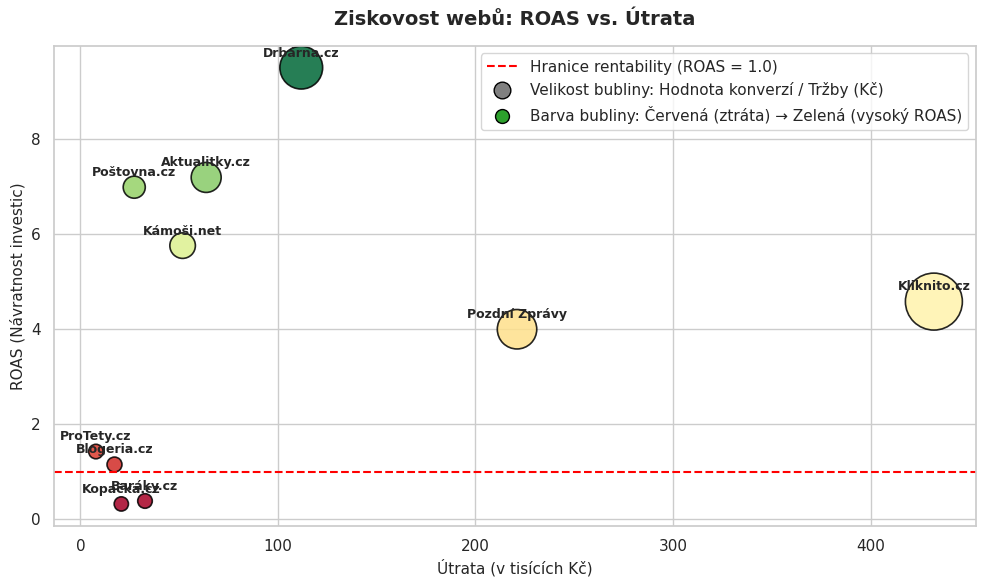

/var/folders/nl/l490bxmx253cbr9z92x4fwhh0000gn/T/ipykernel_723/608063663.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/nl/l490bxmx253cbr9z92x4fwhh0000gn/T/ipykernel_723/608063663.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dev_agg, x="DEVICE_TYPE", y="CPC", ax=axes[1], palette="Oranges_d")


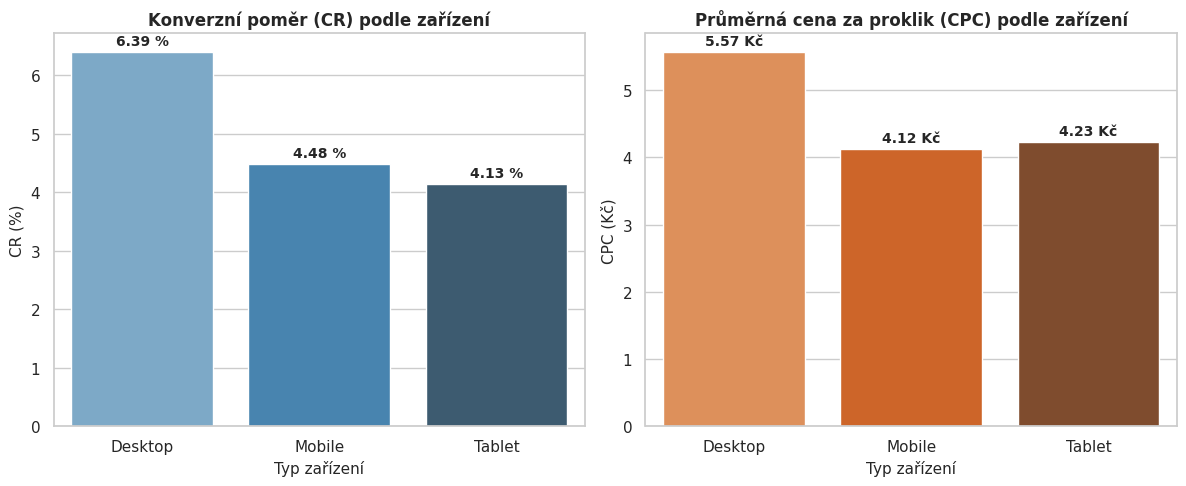

In [58]:

# Nastavení estetiky
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 11})

# --- GRAF 1: Porovnání ziskovosti webů (ROAS vs. Útrata) ---
web_agg = (
    df.groupby("WEB_NAME")[["MONEY", "CONVERSION_VALUE"]].sum().reset_index()
)
web_agg["ROAS"] = web_agg["CONVERSION_VALUE"] / web_agg["MONEY"]
web_agg["MONEY_THOUSANDS"] = web_agg["MONEY"] / 1000
web_agg["CONV_VAL_THOUSANDS"] = (
    web_agg["CONVERSION_VALUE"] / 1000
)  # Převod tržeb na tisíce Kč

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    web_agg["MONEY_THOUSANDS"],
    web_agg["ROAS"],
    s=web_agg["CONV_VAL_THOUSANDS"] * 0.8
    + 100,  # ZMĚNA: Velikost odráží HODNOTU KONVERZÍ
    c=web_agg["ROAS"],
    cmap="RdYlGn",
    alpha=0.85,
    edgecolors="black",
    linewidth=1.2,
)

# Hranice rentability (ROAS = 1.0)
ax.axhline(
    1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Hranice rentability (ROAS = 1.0)",
)

# Anotace názvů webů
for idx, row in web_agg.iterrows():
  ax.annotate(
      row["WEB_NAME"],
      (row["MONEY_THOUSANDS"], row["ROAS"]),
      textcoords="offset points",
      xytext=(0, 8),
      ha="center",
      fontsize=9,
      weight="bold",
  )

# Legenda vysvětlující vlastnosti grafu
legend_elements = [
    Line2D(
        [0],
        [0],
        color="red",
        lw=1.5,
        ls="--",
        label="Hranice rentability (ROAS = 1.0)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Velikost bubliny: Hodnota konverzí / Tržby (Kč)",  # Popis v legendě
        markerfacecolor="gray",
        markersize=12,
        markeredgecolor="black",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Barva bubliny: Červená (ztráta) → Zelená (vysoký ROAS)",
        markerfacecolor="#2ca02c",
        markersize=10,
        markeredgecolor="black",
    ),
]

ax.set_title(
    "Ziskovost webů: ROAS vs. Útrata", fontsize=14, weight="bold", pad=15
)
ax.set_xlabel("Útrata (v tisících Kč)", fontsize=11)
ax.set_ylabel("ROAS (Návratnost investic)", fontsize=11)
ax.legend(handles=legend_elements, loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


# --- GRAF 2: Srovnání CR a CPC napříč hlavními zařízeními ---
main_devices = ["Desktop", "Mobile", "Tablet"]
dev_df = df[df["DEVICE_TYPE"].isin(main_devices)]
dev_agg = (
    dev_df.groupby("DEVICE_TYPE")[["MONEY", "CLICKS", "CONVERSIONS"]]
    .sum()
    .reset_index()
)

dev_agg["CPC"] = dev_agg["MONEY"] / dev_agg["CLICKS"]
dev_agg["CR (%)"] = (dev_agg["CONVERSIONS"] / dev_agg["CLICKS"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Podgraf 1: Konverzní poměr (CR)
sns.barplot(
    data=dev_agg, x="DEVICE_TYPE", y="CR (%)", ax=axes[0], palette="Blues_d"
)
axes[0].set_title(
    "Konverzní poměr (CR) podle zařízení", fontsize=12, weight="bold"
)
axes[0].set_xlabel("Typ zařízení", fontsize=11)
axes[0].set_ylabel("CR (%)", fontsize=11)

for p in axes[0].patches:
  axes[0].annotate(
      f"{p.get_height():.2f} %",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
      fontsize=10,
      weight="bold",
      xytext=(0, 3),
      textcoords="offset points",
  )

# Podgraf 2: Cena za proklik (CPC)
sns.barplot(data=dev_agg, x="DEVICE_TYPE", y="CPC", ax=axes[1], palette="Oranges_d")
axes[1].set_title(
    "Průměrná cena za proklik (CPC) podle zařízení", fontsize=12, weight="bold"
)
axes[1].set_xlabel("Typ zařízení", fontsize=11)
axes[1].set_ylabel("CPC (Kč)", fontsize=11)

for p in axes[1].patches:
  axes[1].annotate(
      f"{p.get_height():.2f} Kč",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
      fontsize=10,
      weight="bold",
      xytext=(0, 3),
      textcoords="offset points",
  )

plt.tight_layout()
plt.show()

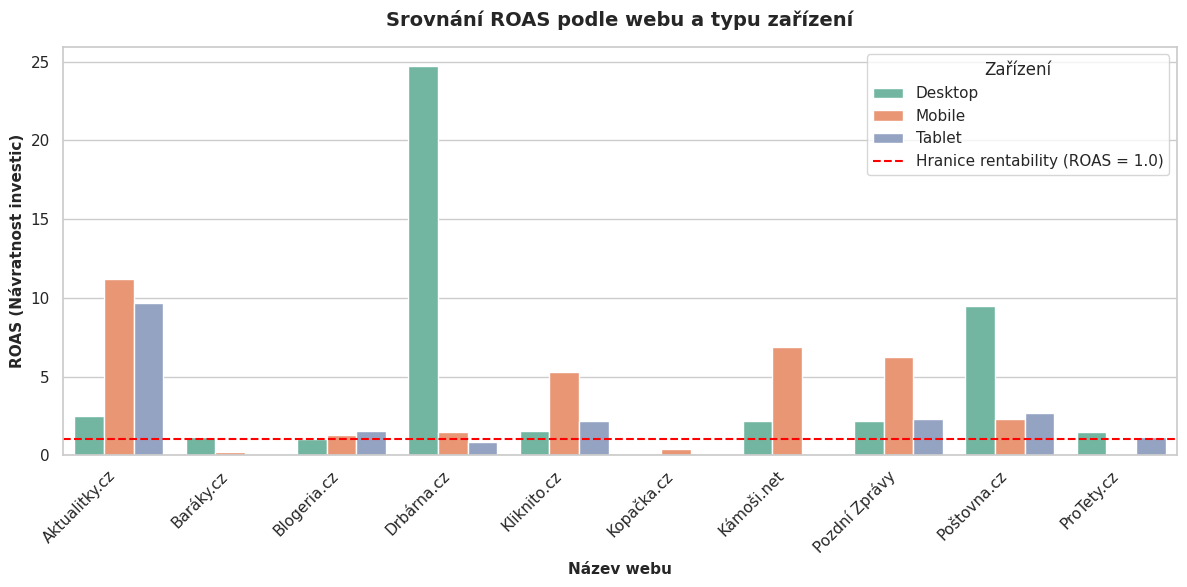

In [59]:
# Sloupcové srovnání ROAS podle webu a typu zařízení
main_devices = ['Desktop', 'Mobile', 'Tablet']
web_dev = df[df['DEVICE_TYPE'].isin(main_devices)].groupby(['WEB_NAME', 'DEVICE_TYPE'])[['MONEY', 'CONVERSION_VALUE']].sum().reset_index()
web_dev['ROAS'] = web_dev['CONVERSION_VALUE'] / web_dev['MONEY']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=web_dev, 
    x='WEB_NAME', 
    y='ROAS', 
    hue='DEVICE_TYPE', 
    palette='Set2', 
    ax=ax
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Hranice rentability (ROAS = 1.0)')
ax.set_title('Srovnání ROAS podle webu a typu zařízení', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Název webu', fontsize=11, weight='bold')
ax.set_ylabel('ROAS (Návratnost investic)', fontsize=11, weight='bold')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Zařízení', loc='upper right')
plt.tight_layout()
plt.show()